# LightGBM Volatility Regime Model

Binary classification baseline for elevated 1-minute volatility regime.

`target = 1` when `abs(return_1m) > q90`, otherwise `0`.

Design choices:
- final holdout test is the last calendar year in the dataset;
- time order is preserved everywhere;
- no shuffle and no forward fill;
- lagged features use only `shift(1+)`;
- rolling features use `rolling(...).mean/std/sum` followed by `shift(1)`;
- q90 is estimated on the train period only, then applied to train/test.

In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

try:
    display
except NameError:
    display = print

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    print("SHAP is unavailable:", exc)

## Settings

In [3]:
DATASET_PATH = Path("model_artifacts/adausdt_minute_log_return_dataset.parquet")
OUTPUT_DIR = Path("model_artifacts/lightgbm_volatility_regime")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "timestamp"
RETURN_COL = "return_1m"
TEST_YEARS = 1
Q = 0.90
N_SPLITS = 5

RANDOM_STATE = 42
DEFAULT_THRESHOLD = 0.5
SHAP_SAMPLE_SIZE = 50_000

BASE_COLUMNS = [
    TIME_COL,
    RETURN_COL,
    "btc_features__btc_log_return",
    "btc_features__btc_zscore",
    "aggression_features__delta_quote_norm",
    "price_pressure__PI_total",
    "price_pressure__F_asymmetry",
    "price_pressure__VWAP_pos",
    "sinthetic_data__sin_hour",
    "sinthetic_data__cos_hour",
    "sinthetic_data__us_open",
    "sinthetic_data__europe_open",
]

MODEL_PARAMS = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

assert DATASET_PATH.exists(), DATASET_PATH

## Load Base Data

In [4]:
df = pd.read_parquet(DATASET_PATH, columns=BASE_COLUMNS)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True)
df = df.sort_values(TIME_COL).reset_index(drop=True)

missing_columns = sorted(set(BASE_COLUMNS) - set(df.columns))
assert not missing_columns, missing_columns

print("rows", len(df))
print("date range", df[TIME_COL].min(), "..", df[TIME_COL].max())
display(df.head())
display(df.tail())

rows 3157919
date range 2020-02-01 00:01:00+00:00 .. 2026-02-01 23:59:00+00:00


,timestamp,return_1m,btc_features__btc_log_return,btc_features__btc_zscore,aggression_features__delta_quote_norm,price_pressure__PI_total,price_pressure__F_asymmetry,price_pressure__VWAP_pos,sinthetic_data__sin_hour,sinthetic_data__cos_hour,sinthetic_data__us_open,sinthetic_data__europe_open
0,2020-02-01 00:01:00+00:00,-0.000743,0.000000,0.000000,-0.498696,-1.730379,6201.867676,-0.576742,0.004363,0.999990,0,0
1,2020-02-01 00:02:00+00:00,0.000186,-0.000325,-0.707107,0.438980,1.534069,0.000045,-0.720384,0.008727,0.999962,0,0
2,2020-02-01 00:03:00+00:00,-0.001859,-0.000177,-0.059236,0.018052,2.636704,-0.000212,0.272863,0.013090,0.999914,0,0
3,2020-02-01 00:04:00+00:00,-0.000745,-0.000712,-1.347792,-0.151561,2.917168,-0.000032,0.018353,0.017452,0.999848,0,0
4,2020-02-01 00:05:00+00:00,0.000932,0.000410,1.381718,-0.353434,2.400783,-0.000051,0.045497,0.021815,0.999762,0,0


,timestamp,return_1m,btc_features__btc_log_return,btc_features__btc_zscore,aggression_features__delta_quote_norm,price_pressure__PI_total,price_pressure__F_asymmetry,price_pressure__VWAP_pos,sinthetic_data__sin_hour,sinthetic_data__cos_hour,sinthetic_data__us_open,sinthetic_data__europe_open
3157914,2026-02-01 23:55:00+00:00,0.000701,0.000075,0.057059,-0.252914,-110.204201,-6684.175293,-0.351339,-0.021815,0.999762,0,0
3157915,2026-02-01 23:56:00+00:00,0.001400,0.000385,0.209566,0.402227,5.354596,0.000642,0.383614,-0.017452,0.999848,0,0
3157916,2026-02-01 23:57:00+00:00,-0.002097,0.001520,0.710436,0.187168,-24.592688,18398.556641,0.071203,-0.013090,0.999914,0,0
3157917,2026-02-01 23:58:00+00:00,0.000350,-0.001138,-0.488871,-0.098073,-17.571518,2080.092773,-0.153871,-0.008727,0.999962,0,0
3157918,2026-02-01 23:59:00+00:00,0.001050,-0.000877,-0.370770,-0.035795,-3.517723,1635.878784,0.529076,-0.004363,0.999990,0,0


## Feature Engineering

In [5]:
def shifted_rolling_mean(series, window):
    return series.rolling(window=window, min_periods=window).mean().shift(1)


def shifted_rolling_std(series, window):
    return series.rolling(window=window, min_periods=window).std(ddof=0).shift(1)


def shifted_rolling_abs_sum(series, window):
    return series.abs().rolling(window=window, min_periods=window).sum().shift(1)


features = pd.DataFrame(index=df.index)

# 1. Lagged returns.
features["return_lag_1"] = df[RETURN_COL].shift(1)
features["return_lag_2"] = df[RETURN_COL].shift(2)
features["return_lag_3"] = df[RETURN_COL].shift(3)

# 2. BTC features.
features["btc_zscore_lag_1"] = df["btc_features__btc_zscore"].shift(1)
features["btc_zscore_lag_5"] = df["btc_features__btc_zscore"].shift(5)
features["btc_volatility_15"] = shifted_rolling_std(df["btc_features__btc_log_return"], 15)

# 3. Aggression features.
delta_quote_norm = df["aggression_features__delta_quote_norm"]
features["delta_quote_norm_lag_1"] = delta_quote_norm.shift(1)
features["delta_quote_norm_lag_2"] = delta_quote_norm.shift(2)
features["rolling_delta_5"] = shifted_rolling_mean(delta_quote_norm, 5)
features["rolling_delta_15"] = shifted_rolling_mean(delta_quote_norm, 15)
features["rolling_abs_delta_30"] = shifted_rolling_abs_sum(delta_quote_norm, 30)

# 4. Pressure features.
features["PI_total_lag_1"] = df["price_pressure__PI_total"].shift(1)
features["F_asymmetry_lag_1"] = df["price_pressure__F_asymmetry"].shift(1)
features["VWAP_pos_lag_1"] = df["price_pressure__VWAP_pos"].shift(1)

# 5. Volatility features from ADA returns.
features["rolling_std_5"] = shifted_rolling_std(df[RETURN_COL], 5)
features["rolling_std_15"] = shifted_rolling_std(df[RETURN_COL], 15)
features["rolling_std_30"] = shifted_rolling_std(df[RETURN_COL], 30)

# 6. Time features are deterministic at timestamp t.
features["sin_hour"] = df["sinthetic_data__sin_hour"]
features["cos_hour"] = df["sinthetic_data__cos_hour"]
features["us_open"] = df["sinthetic_data__us_open"]
features["europe_open"] = df["sinthetic_data__europe_open"]

feature_cols = features.columns.tolist()

model_df = pd.concat([df[[TIME_COL, RETURN_COL]], features], axis=1)
nan_rows_before = int(model_df[feature_cols].isna().any(axis=1).sum())
model_df = model_df.dropna(subset=feature_cols + [RETURN_COL]).reset_index(drop=True)

print("feature columns", len(feature_cols))
print("dropped rows after lag/rolling generation", nan_rows_before)
display(pd.DataFrame({"feature": feature_cols}))
display(model_df[[TIME_COL, RETURN_COL] + feature_cols].head())

feature columns 21
dropped rows after lag/rolling generation 30


,feature
0,return_lag_1
1,return_lag_2
2,return_lag_3
3,btc_zscore_lag_1
4,btc_zscore_lag_5
5,btc_volatility_15
6,delta_quote_norm_lag_1
7,delta_quote_norm_lag_2
8,rolling_delta_5
9,rolling_delta_15


,timestamp,return_1m,return_lag_1,return_lag_2,return_lag_3,btc_zscore_lag_1,btc_zscore_lag_5,btc_volatility_15,delta_quote_norm_lag_1,delta_quote_norm_lag_2,rolling_delta_5,rolling_delta_15,rolling_abs_delta_30,PI_total_lag_1,F_asymmetry_lag_1,VWAP_pos_lag_1,rolling_std_5,rolling_std_15,rolling_std_30,sin_hour,cos_hour,us_open,europe_open
0,2020-02-01 00:31:00+00:00,0.000743,-0.001114,0.000371,0.000000,0.847957,0.277400,0.000388,-0.210370,-0.479849,-0.332185,-0.096384,10.475568,3.882918,0.000063,0.384383,0.001209,0.000903,0.001033,0.134851,0.990866,0,0
1,2020-02-01 00:32:00+00:00,0.000000,0.000743,-0.001114,0.000371,0.260339,-0.040747,0.000391,0.176156,-0.210370,-0.160773,-0.097540,10.153028,-0.237098,-886.675354,-0.421793,0.001209,0.000904,0.001032,0.139173,0.990268,0,0
2,2020-02-01 00:33:00+00:00,-0.000557,0.000000,0.000743,-0.001114,0.116875,-1.828080,0.000391,0.922496,0.176156,-0.029899,-0.018543,10.636545,0.238375,0.000208,0.399846,0.000622,0.000902,0.001031,0.143493,0.989651,0,0
3,2020-02-01 00:34:00+00:00,-0.000186,-0.000557,0.000000,0.000743,0.380115,0.980541,0.000396,0.177029,0.922496,0.117092,0.021001,10.795522,1.475360,-0.000122,0.150860,0.000660,0.000869,0.000977,0.147809,0.989016,0,0
4,2020-02-01 00:35:00+00:00,0.000929,-0.000186,-0.000557,0.000000,-0.927767,0.847957,0.000404,-0.941381,0.177029,0.024786,-0.008810,11.585342,0.495450,0.000702,-0.048666,0.000615,0.000867,0.000966,0.152123,0.988362,0,0


## Train / Test Split

The final test set is the last calendar year. The q90 threshold is estimated on train only to avoid leaking the test distribution into target construction.

In [6]:
max_time = model_df[TIME_COL].max()
test_start = max_time - pd.DateOffset(years=TEST_YEARS)

train_mask = model_df[TIME_COL] < test_start
test_mask = model_df[TIME_COL] >= test_start

train_df = model_df.loc[train_mask].copy().reset_index(drop=True)
test_df = model_df.loc[test_mask].copy().reset_index(drop=True)

q90 = float(train_df[RETURN_COL].abs().quantile(Q))
train_df["target"] = (train_df[RETURN_COL].abs() > q90).astype("int8")
test_df["target"] = (test_df[RETURN_COL].abs() > q90).astype("int8")

X_train = train_df[feature_cols]
y_train = train_df["target"]
X_test = test_df[feature_cols]
y_test = test_df["target"]

split_report = {
    "q90_train_abs_return": q90,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_start": str(train_df[TIME_COL].min()),
    "train_end": str(train_df[TIME_COL].max()),
    "test_start": str(test_df[TIME_COL].min()),
    "test_end": str(test_df[TIME_COL].max()),
    "train_positive_rate": float(y_train.mean()),
    "test_positive_rate": float(y_test.mean()),
}

display(pd.DataFrame([split_report]))
display(pd.DataFrame({"target": [0, 1], "train_count": y_train.value_counts().reindex([0, 1]).fillna(0).astype(int).to_numpy(), "test_count": y_test.value_counts().reindex([0, 1]).fillna(0).astype(int).to_numpy()}))

,q90_train_abs_return,train_rows,test_rows,train_start,train_end,test_start,test_end,train_positive_rate,test_positive_rate
0,0.002117,2632288,525601,2020-02-01 00:31:00+00:00,2025-02-01 23:58:00+00:00,2025-02-01 23:59:00+00:00,2026-02-01 23:59:00+00:00,0.1,0.073881


,target,train_count,test_count
0,0,2369059,486769
1,1,263229,38832


## Metrics Helpers

In [7]:
def evaluate_binary(y_true, proba, threshold=DEFAULT_THRESHOLD):
    pred = (proba >= threshold).astype("int8")
    return {
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "pr_auc": float(average_precision_score(y_true, proba)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "tn": int(confusion_matrix(y_true, pred, labels=[0, 1])[0, 0]),
        "fp": int(confusion_matrix(y_true, pred, labels=[0, 1])[0, 1]),
        "fn": int(confusion_matrix(y_true, pred, labels=[0, 1])[1, 0]),
        "tp": int(confusion_matrix(y_true, pred, labels=[0, 1])[1, 1]),
        "positive_rate_true": float(np.mean(y_true)),
        "positive_rate_pred": float(np.mean(pred)),
    }


def find_best_f1_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    if len(thresholds) == 0:
        return DEFAULT_THRESHOLD, 0.0
    f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    best_idx = int(np.nanargmax(f1_values))
    return float(thresholds[best_idx]), float(f1_values[best_idx])


def baseline_metrics(y_true):
    constant = np.full(len(y_true), float(y_train.mean()))
    return evaluate_binary(y_true, constant)


def make_model():
    return LGBMClassifier(**MODEL_PARAMS)

## Time-Series Cross-Validation On Train

In [8]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
fold_rows = []

for fold, (fit_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_fit, y_fit = X_train.iloc[fit_idx], y_train.iloc[fit_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    model = make_model()
    model.fit(
        X_fit,
        y_fit,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[early_stopping(50), log_evaluation(100)],
    )

    proba = model.predict_proba(X_val)[:, 1]
    row = {
        "fold": fold,
        "fit_rows": int(len(fit_idx)),
        "val_rows": int(len(val_idx)),
        "fit_start": str(train_df[TIME_COL].iloc[fit_idx[0]]),
        "fit_end": str(train_df[TIME_COL].iloc[fit_idx[-1]]),
        "val_start": str(train_df[TIME_COL].iloc[val_idx[0]]),
        "val_end": str(train_df[TIME_COL].iloc[val_idx[-1]]),
        "best_iteration": int(model.best_iteration_ or MODEL_PARAMS["n_estimators"]),
    }
    row.update(evaluate_binary(y_val.to_numpy(), proba))
    row["baseline_roc_auc"] = 0.5
    row["baseline_pr_auc"] = float(y_fit.mean())
    fold_rows.append(row)

fold_metrics_df = pd.DataFrame(fold_rows)
display(fold_metrics_df)
display(fold_metrics_df[["roc_auc", "pr_auc", "f1"]].agg(["mean", "std", "min", "max"]))

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.792393
[200]	valid_0's auc: 0.792981
Early stopping, best iteration is:
[203]	valid_0's auc: 0.792986
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.804303
[200]	valid_0's auc: 0.805283
[300]	valid_0's auc: 0.805689
[400]	valid_0's auc: 0.806007
[500]	valid_0's auc: 0.806136
Did not meet early stopping. Best iteration is:
[499]	valid_0's auc: 0.806137
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.845518
[200]	valid_0's auc: 0.847375
[300]	valid_0's auc: 0.847703
Early stopping, best iteration is:
[314]	valid_0's auc: 0.847767
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.861544
[200]	valid_0's auc: 0.86294
[300]	valid_0's auc: 0.863382
[400]	valid_0's auc: 0.863523
[500]	valid_0's auc: 0.863658
Did not meet early stopping. Best iteration is:
[498]	valid_0's auc: 0.863661
Training until valida

,fold,fit_rows,val_rows,fit_start,fit_end,val_start,val_end,best_iteration,roc_auc,pr_auc,f1,tn,fp,fn,tp,positive_rate_true,positive_rate_pred,baseline_roc_auc,baseline_pr_auc
0,1,438718,438714,2020-02-01 00:31:00+00:00,2020-12-01 16:28:00+00:00,2020-12-01 16:29:00+00:00,2021-10-02 08:22:00+00:00,203,0.792986,0.508918,0.402671,326175,19582,64587,28370,0.211885,0.109301,0.5,0.108746
1,2,877432,438714,2020-02-01 00:31:00+00:00,2021-10-02 08:22:00+00:00,2021-10-02 08:23:00+00:00,2022-08-03 00:16:00+00:00,499,0.806137,0.369849,0.219919,387704,4640,40068,6302,0.105695,0.024941,0.5,0.160316
2,3,1316146,438714,2020-02-01 00:31:00+00:00,2022-08-03 00:16:00+00:00,2022-08-03 00:17:00+00:00,2023-06-03 16:10:00+00:00,314,0.847767,0.258015,0.129275,421045,993,15455,1221,0.038011,0.005047,0.5,0.142109
3,4,1754860,438714,2020-02-01 00:31:00+00:00,2023-06-03 16:10:00+00:00,2023-06-03 16:11:00+00:00,2024-04-03 08:04:00+00:00,498,0.863661,0.304194,0.137813,413662,1496,21702,1854,0.053693,0.007636,0.5,0.116084
4,5,2193574,438714,2020-02-01 00:31:00+00:00,2024-04-03 08:04:00+00:00,2024-04-03 08:05:00+00:00,2025-02-01 23:58:00+00:00,498,0.857558,0.377571,0.202489,399575,3178,31552,4409,0.081969,0.017294,0.5,0.103606


,roc_auc,pr_auc,f1
mean,0.833622,0.363709,0.218433
std,0.031946,0.094906,0.110282
min,0.792986,0.258015,0.129275
max,0.863661,0.508918,0.402671


## Final Holdout Model

In [9]:
validation_size = max(int(len(X_train) * 0.15), 10_000)
X_fit = X_train.iloc[:-validation_size]
y_fit = y_train.iloc[:-validation_size]
X_val = X_train.iloc[-validation_size:]
y_val = y_train.iloc[-validation_size:]

final_model = make_model()
final_model.fit(
    X_fit,
    y_fit,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[early_stopping(50), log_evaluation(100)],
)

val_proba = final_model.predict_proba(X_val)[:, 1]
best_f1_threshold, validation_best_f1 = find_best_f1_threshold(y_val.to_numpy(), val_proba)
test_proba = final_model.predict_proba(X_test)[:, 1]
final_metrics_default_threshold = evaluate_binary(y_test.to_numpy(), test_proba, threshold=DEFAULT_THRESHOLD)
final_metrics = evaluate_binary(y_test.to_numpy(), test_proba, threshold=best_f1_threshold)
final_metrics.update({
    "best_iteration": int(final_model.best_iteration_ or MODEL_PARAMS["n_estimators"]),
    "threshold": best_f1_threshold,
    "validation_best_f1": validation_best_f1,
    "baseline_roc_auc": 0.5,
    "baseline_pr_auc": float(y_train.mean()),
})
final_metrics_default_threshold.update({
    "threshold": DEFAULT_THRESHOLD,
    "best_iteration": int(final_model.best_iteration_ or MODEL_PARAMS["n_estimators"]),
})

final_metrics_df = pd.DataFrame([final_metrics])
final_default_threshold_metrics_df = pd.DataFrame([final_metrics_default_threshold])
print("Metrics with validation-selected F1 threshold")
display(final_metrics_df)
display(pd.DataFrame(confusion_matrix(y_test, test_proba >= best_f1_threshold, labels=[0, 1]), index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]))
print("Metrics with default threshold 0.5")
display(final_default_threshold_metrics_df)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.860736
[200]	valid_0's auc: 0.861877
[300]	valid_0's auc: 0.862191
[400]	valid_0's auc: 0.862308
[500]	valid_0's auc: 0.862458
Did not meet early stopping. Best iteration is:
[499]	valid_0's auc: 0.862458
Metrics with validation-selected F1 threshold


,roc_auc,pr_auc,f1,tn,fp,fn,tp,positive_rate_true,positive_rate_pred,best_iteration,threshold,validation_best_f1,baseline_roc_auc,baseline_pr_auc
0,0.82984,0.332796,0.375253,448891,37878,21115,17717,0.073881,0.105774,499,0.194394,0.426922,0.5,0.1


,pred_0,pred_1
actual_0,448891,37878
actual_1,21115,17717


Metrics with default threshold 0.5


,roc_auc,pr_auc,f1,tn,fp,fn,tp,positive_rate_true,positive_rate_pred,threshold,best_iteration
0,0.82984,0.332796,0.163906,484310,2459,35146,3686,0.073881,0.011691,0.5,499


## ROC And PR Curves

WindowsPath('model_artifacts/lightgbm_volatility_regime/roc_pr_curves.png')

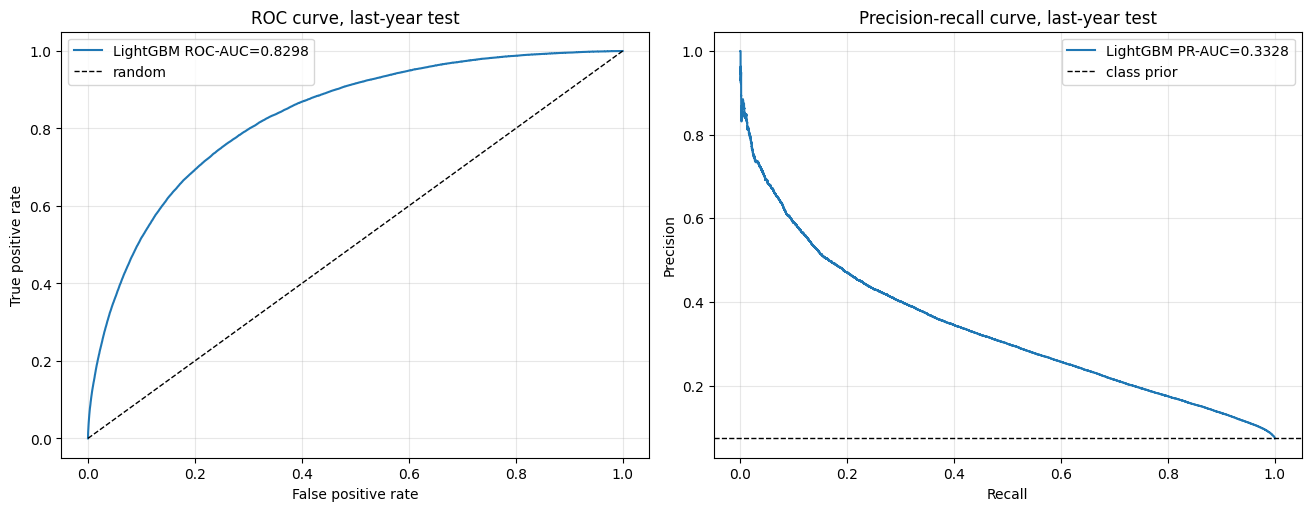

In [10]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
precision, recall, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].plot(fpr, tpr, label=f"LightGBM ROC-AUC={final_metrics['roc_auc']:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="random")
axes[0].set_title("ROC curve, last-year test")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall, precision, label=f"LightGBM PR-AUC={final_metrics['pr_auc']:.4f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=1, label="class prior")
axes[1].set_title("Precision-recall curve, last-year test")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

roc_plot_path = OUTPUT_DIR / "roc_pr_curves.png"
fig.savefig(roc_plot_path, dpi=160)
roc_plot_path

## Feature Importance

,feature,importance_gain,importance_split
0,rolling_std_30,2.241254e+06,1028
1,rolling_std_15,4.044106e+05,815
2,rolling_std_5,1.655194e+05,810
3,return_lag_1,6.982847e+04,1325
4,PI_total_lag_1,4.023058e+04,783
5,cos_hour,3.061641e+04,1068
6,rolling_abs_delta_30,2.928783e+04,806
7,return_lag_2,2.913490e+04,908
8,btc_volatility_15,2.319176e+04,737
9,sin_hour,2.249700e+04,969


WindowsPath('model_artifacts/lightgbm_volatility_regime/top_feature_importance.png')

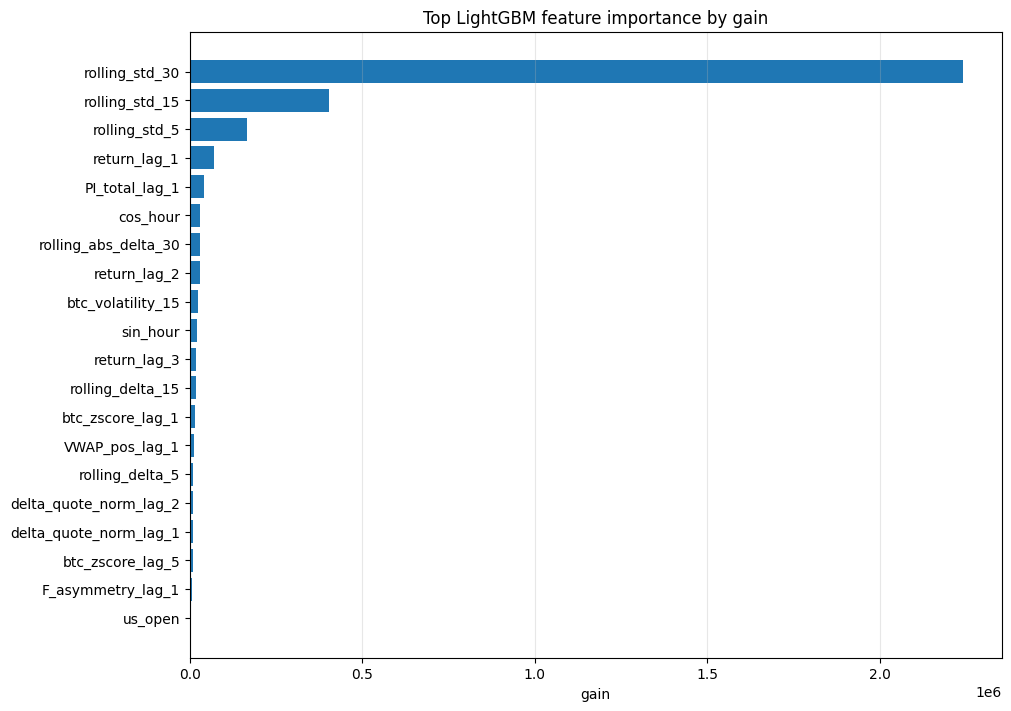

In [11]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_gain": final_model.booster_.feature_importance(importance_type="gain"),
    "importance_split": final_model.booster_.feature_importance(importance_type="split"),
}).sort_values("importance_gain", ascending=False).reset_index(drop=True)

display(importance_df)

top_n = min(20, len(importance_df))
fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
plot_df = importance_df.head(top_n).sort_values("importance_gain")
ax.barh(plot_df["feature"], plot_df["importance_gain"], color="tab:blue")
ax.set_title("Top LightGBM feature importance by gain")
ax.set_xlabel("gain")
ax.grid(True, axis="x", alpha=0.3)
importance_plot_path = OUTPUT_DIR / "top_feature_importance.png"
fig.savefig(importance_plot_path, dpi=160)
importance_plot_path

## SHAP Importance

,feature,mean_abs_shap
0,rolling_std_30,0.717159
1,rolling_std_15,0.194507
2,return_lag_1,0.131550
3,btc_volatility_15,0.081959
4,PI_total_lag_1,0.080254
5,return_lag_2,0.074100
6,rolling_abs_delta_30,0.057272
7,rolling_std_5,0.050312
8,sin_hour,0.037638
9,return_lag_3,0.036314


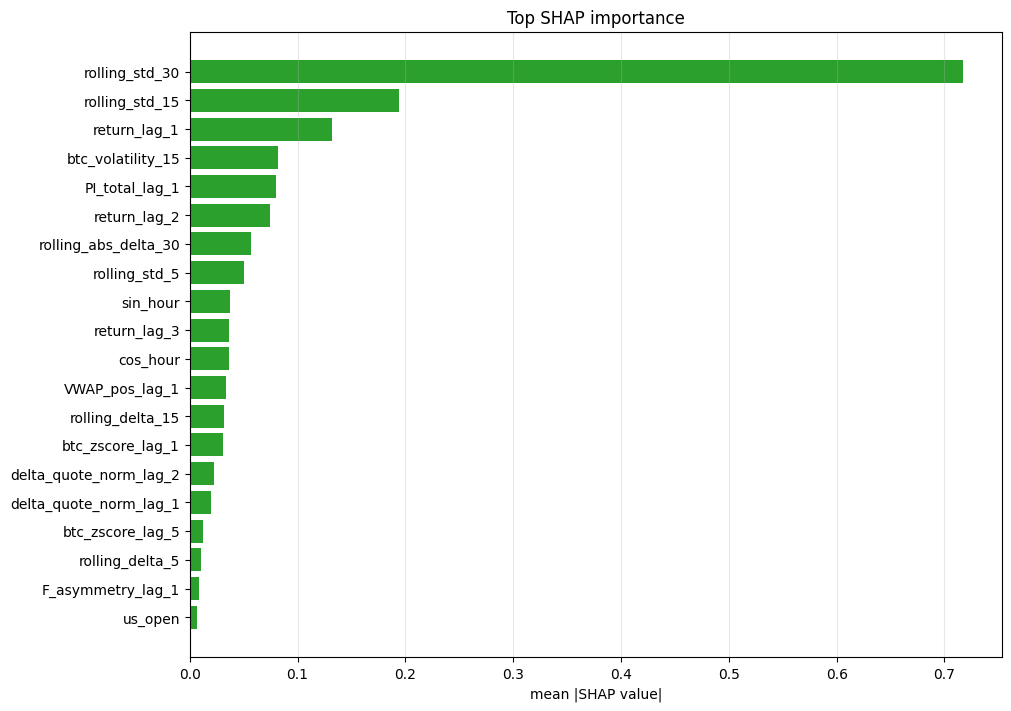

In [12]:
if SHAP_AVAILABLE:
    shap_sample = X_test.sample(n=min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(shap_sample)
    if isinstance(shap_values, list):
        shap_matrix = shap_values[1]
    else:
        shap_matrix = shap_values

    shap_importance_df = pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    display(shap_importance_df)

    fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
    plot_df = shap_importance_df.head(min(20, len(shap_importance_df))).sort_values("mean_abs_shap")
    ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color="tab:green")
    ax.set_title("Top SHAP importance")
    ax.set_xlabel("mean |SHAP value|")
    ax.grid(True, axis="x", alpha=0.3)
    shap_plot_path = OUTPUT_DIR / "top_shap_importance.png"
    fig.savefig(shap_plot_path, dpi=160)
else:
    shap_importance_df = pd.DataFrame(columns=["feature", "mean_abs_shap"])
    shap_plot_path = None
    print("SHAP skipped because shap is not installed or failed to import.")

## Save Outputs

In [13]:
fold_metrics_df.to_csv(OUTPUT_DIR / "time_series_fold_metrics.csv", index=False)
final_metrics_df.to_csv(OUTPUT_DIR / "final_holdout_metrics.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "lightgbm_feature_importance.csv", index=False)
importance_df.head(20).to_csv(OUTPUT_DIR / "top_important_features.csv", index=False)
shap_importance_df.to_csv(OUTPUT_DIR / "shap_importance.csv", index=False)

predictions_df = test_df[[TIME_COL, RETURN_COL, "target"]].copy()
predictions_df["predicted_probability"] = test_proba
predictions_df["predicted_label"] = (test_proba >= best_f1_threshold).astype("int8")
predictions_df["predicted_label_threshold_0_5"] = (test_proba >= DEFAULT_THRESHOLD).astype("int8")
predictions_df.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=False, compression="zstd")

report = {
    "dataset": str(DATASET_PATH),
    "output_dir": str(OUTPUT_DIR),
    "target_definition": f"abs({RETURN_COL}) > train q{int(Q * 100)}",
    "split": split_report,
    "feature_columns": feature_cols,
    "model_params": MODEL_PARAMS,
    "final_metrics": final_metrics,
    "final_metrics_default_threshold": final_metrics_default_threshold,
    "fold_metrics": fold_metrics_df.to_dict(orient="records"),
    "plots": {
        "roc_pr": str(roc_plot_path),
        "feature_importance": str(importance_plot_path),
        "shap_importance": str(shap_plot_path) if shap_plot_path is not None else None,
    },
}
(OUTPUT_DIR / "lightgbm_volatility_regime_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")

print("saved to", OUTPUT_DIR)

saved to model_artifacts\lightgbm_volatility_regime
